# 04b — Análise Qualitativa

**Escopo qualitativo real** (descobertas após inspeção):
- Q9: 5 palavras associadas a qualidade de dados — lematização (RSLP) + frequência por posição
- Q10: experiência em Engenharia de Requisitos — texto livre real (32 respostas)
- Q12: justificativa importância — texto livre (12 respostas)
- Q14: justificativa prioridade — texto livre (9 respostas)
- Q15: equilíbrio entre características — texto livre (31 respostas)

**Procedimento**:
1. Coding único por mim (codificador 1) — declarar como ameaça à validade
2. Categorias emergentes (open coding) → axial coding em temas amplos
3. Codebook tabular: categoria → subcategoria → quotes ilustrativas → frequência
4. Lematização Q9 com `nltk.RSLPStemmer` + análise por posição (1ª palavra = topo de mente)
5. Findings boxes textuais

**Limitação assumida**: GT "clássico" requer 2+ codificadores e cálculo de Cohen's κ. Aqui temos 1 codificador → declarado como threat to construct validity. Codebook publicado no replication package permite re-coding por terceiros.

In [1]:
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"

# Garantir recursos NLTK
for resource in ["rslp", "stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource, quiet=True)

from nltk.stem import RSLPStemmer
from nltk.corpus import stopwords as nltk_stopwords

stemmer = RSLPStemmer()
STOPWORDS_PT = set(nltk_stopwords.words("portuguese"))
STOPWORDS_PT |= {"sim", "nao", "não", "ja", "já", "ainda", "talvez", "sempre", "nunca",
                  ".", "...", "…"}

df = U.load_anonymized()
words_long = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)} | tokens Q9={len(words_long)}")

N=32 | tokens Q9=160


## 1. Q9 — lematização e frequência por posição

RSLP: stemmer português leve. Não é lematização full mas agrupa variações morfológicas ("precisão"/"preciso" → "precis"). Após stemming, mapeia stem → forma canônica mais frequente para visualização.

In [2]:
def stem_pt(token: str) -> str:
    t = token.strip().lower()
    # Remove pontuação solta
    t = re.sub(r"[^\wáéíóúâêôãõç]", "", t)
    if not t or t in STOPWORDS_PT:
        return ""
    return stemmer.stem(t)

words_long["stem"] = words_long["word"].apply(stem_pt)
words_long = words_long[words_long["stem"] != ""].copy()

# Mapear stem → forma canônica (palavra mais frequente que produz aquele stem)
stem_to_form = (words_long.groupby(["stem", "word"]).size()
                .reset_index(name="freq")
                .sort_values(["stem", "freq"], ascending=[True, False])
                .drop_duplicates("stem")
                .set_index("stem")["word"])
words_long["canonical"] = words_long["stem"].map(stem_to_form)
print(words_long.head(10))
print(f"\nTokens após stopwords: {len(words_long)}")
print(f"Stems únicos: {words_long['stem'].nunique()}")

   position            word     stem       canonical
0         1        precisão   precis        precisão
1         1           fonte     font           fonte
2         1  confiabilidade    confi  confiabilidade
3         1           ruído     ruíd           ruído
4         1        precisão   precis        precisão
5         1    consistência  consist    consistência
6         1          treino    trein          treino
7         1   balanceamento  balance   balanceamento
8         1  confiabilidade    confi  confiabilidade
9         1       qualidade     qual       qualidade

Tokens após stopwords: 159
Stems únicos: 93


In [3]:
# Frequência geral por canonical
freq_total = words_long["canonical"].value_counts().head(20)
print("=== Top-20 lematizado ===")
print(freq_total)

=== Top-20 lematizado ===
canonical
consistência       10
precisão            8
confiabilidade      8
relevância          7
completude          7
atualização         7
qualidade           4
quantidade          4
integração          4
acurácia            3
balanceamento       2
corretude           2
limpeza             2
disponibilidade     2
diversidade         2
validade            2
viés                2
segurança           2
reuso               2
organizados         2
Name: count, dtype: int64


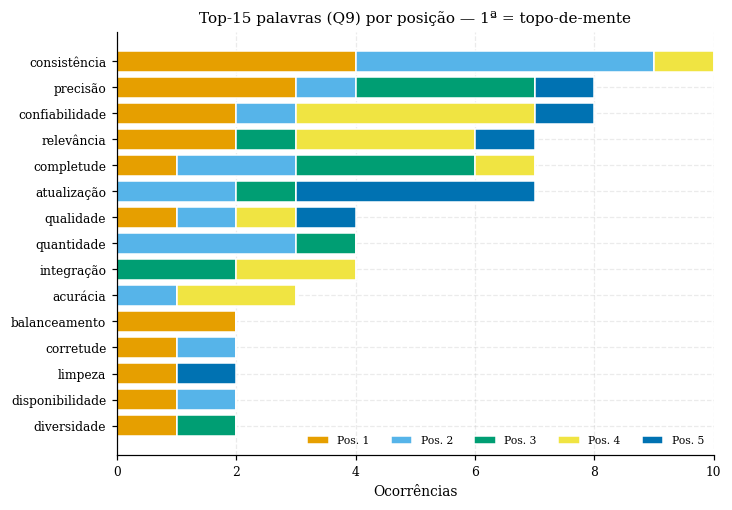

In [4]:
# Frequência por posição: 1ª palavra (topo-de-mente) vs 5ª palavra
fig, ax = plt.subplots(figsize=(7.0, 5.0))
top_overall = freq_total.head(15).index.tolist()
by_pos = (words_long[words_long["canonical"].isin(top_overall)]
          .groupby(["canonical", "position"]).size()
          .unstack(fill_value=0)
          .reindex(top_overall))
by_pos = by_pos.iloc[::-1]  # Inverter para barras horizontais
y = np.arange(len(by_pos))
bottom = np.zeros(len(by_pos))
colors = U.PALETTE_WONG[1:6]
for pos in [1, 2, 3, 4, 5]:
    if pos not in by_pos.columns:
        continue
    width = by_pos[pos].values
    ax.barh(y, width, left=bottom, color=colors[pos - 1],
            edgecolor="white", label=f"Pos. {pos}")
    bottom += width
ax.set_yticks(y)
ax.set_yticklabels(by_pos.index)
ax.set_xlabel("Ocorrências")
ax.set_title("Top-15 palavras (Q9) por posição — 1ª = topo-de-mente")
ax.legend(loc="lower right", frameon=False, ncol=5, fontsize=7)
U.save_fig(fig, "words_by_position")
plt.show()

In [5]:
# Top-3 da 1ª posição (palavra mais top-de-mente)
first_word_top = (words_long[words_long["position"] == 1]["canonical"]
                  .value_counts().head(5))
print("Palavras mais frequentes na 1ª posição (topo-de-mente):")
print(first_word_top)
print()
fifth_word_top = (words_long[words_long["position"] == 5]["canonical"]
                  .value_counts().head(5))
print("Palavras mais frequentes na 5ª posição (mais distantes):")
print(fifth_word_top)

Palavras mais frequentes na 1ª posição (topo-de-mente):
canonical
consistência      4
precisão          3
confiabilidade    2
balanceamento     2
relevância        2
Name: count, dtype: int64

Palavras mais frequentes na 5ª posição (mais distantes):
canonical
atualização      4
viés             1
determinante     1
processamento    1
validação        1
Name: count, dtype: int64


## 2. Q10 — Experiência em Engenharia de Requisitos

Open coding manual (codificador 1: este notebook). 32 respostas. Categorias emergentes:

In [6]:
# Codificação manual baseada em leitura prévia das 32 respostas
# Cada respondente pode ter MÚLTIPLOS códigos
Q10_CODES = {
    # respondent_id: (códigos atribuídos, quote ilustrativa curta)
    0: (["experiencia_positiva_geral"], "foi uma ótima experiência, embora complicada"),
    1: (["sem_experiencia"], "Não"),
    2: (["experiencia_inicial_projeto"], "primeiros passos quando começamos um projeto"),
    3: (["requisitos_para_modelo_ml_distintos", "colaboracao_com_qa", "alinhamento_stakeholders"],
        "levantei a necessidade de termos requisitos claros... para o modelo, para alinhar comportamento e performance às expectativas dos stakeholders"),
    4: (["experiencia_completa_ciclo"], "todas as fases do ciclo de um projeto em Ciência de Dados"),
    5: (["sem_experiencia"], "Não"),
    6: (["sem_experiencia"], "Não"),
    7: (["experiencia_diversificada"], "projetos de diversas aplicações, metodologias e tecnologias"),
    8: (["documentacao_formal"], "Registro formal dos requisitos em documentos detalhados, especificações funcionais e não funcionais, casos de uso"),
    9: (["experiencia_apenas_academica"], "apenas em trabalhos acadêmicos"),
    10: (["elicitacao_estruturada"], "elicitação de requisitos, análise de documentos e entrevistas semiestruturadas"),
    11: (["sem_experiencia"], "Nunca participei"),
    12: (["experiencia_apenas_academica", "reconhecimento_importancia"],
         "em disciplinas na universidade... extrema importância porque era o que nos guiava no desenvolvimento"),
    13: (["papel_periferico", "foco_documentacao_codigo"],
         "mais voltada para a documentação do código e na criação de diagramas referentes a pipelines"),
    14: (["foco_dependencias"], "Somente documentação de dependências e bibliotecas"),
    15: (["refinamento_iterativo", "discussao_complexidade"],
         "refinamento de requisitos, discutimos com a equipe a complexidade e capacidade do time"),
    16: (["requisitos_processo_negocio"],
         "escopo analise e desenho dos processos de negócio implicados na mudança"),
    17: (["sem_experiencia"], "Não"),
    18: (["experiencia_minima"], "Sim"),
    19: (["prazos_curtos_limitam", "foco_coleta", "variabilidade_porte_empresa"],
         "prazos sempre foram extremamente curtos para realizar um estudo aprofundado... empresas com menor capital tendem a ser mais exploratórias e desorganizadas"),
    20: (["sem_experiencia"], "Nunca participei de atividades de engenharia de requisitos"),
    21: (["resposta_vazia"], "…"),
    22: (["foco_funcionais_apis"], "requisitos funcionais como integrações utilizando API e cadastros de usuarios"),
    23: (["dependencia_especialistas_dominio", "trabalho_demorado"],
         "trabalhoso e demorado, pois é preciso ter o entendimento do contexto de negócio... regras estão na cabeça do usuário"),
    24: (["sem_experiencia"], "Não"),
    25: (["experiencia_completa_ciclo", "avaliacao_viabilidade"],
         "descrever e avaliar a viabilidade na fase de concepção"),
    26: (["reconhecimento_importancia", "prevencao_atritos"],
         "etapa crucial para a definição de um bom escopo, evitando atritos entre a equipe e o cliente"),
    27: (["elicitacao_informal", "sem_documento_formal"],
         "de maneira informal com os membros relevantes do time em uma reunião, sem geração de um documento formalizando tudo"),
    28: (["jornadas_usuario", "foco_publico_alvo"],
         "jornadas de usuário conversando com clientes para entender como um produto de IA poderia ajudar no cotidiano"),
    29: (["refinamento_iterativo", "levantamento_cenarios", "requisitos_funcionais_e_nfr"],
         "reunião com o cliente onde ele faz o levantamento dos cenários... criação das Histórias, Cenários e Requisitos Funcionais e Não Funcionais"),
    30: (["experiencia_completa_ciclo", "analise_sistemas_anteriores", "prototipos"],
         "análise de sistemas anteriores e documentações existentes, além de entrevistas e confecção de protótipos"),
    31: (["sem_experiencia"], "Não"),
}

Q10_CATEGORIES = {
    "sem_experiencia": "Sem experiência em ER",
    "experiencia_apenas_academica": "Experiência apenas acadêmica",
    "experiencia_completa_ciclo": "Experiência em todas as fases",
    "experiencia_diversificada": "Experiência em projetos diversos",
    "experiencia_minima": "Experiência mínima/sem detalhes",
    "experiencia_inicial_projeto": "ER como primeiros passos do projeto",
    "experiencia_positiva_geral": "Experiência positiva genérica",
    "requisitos_para_modelo_ml_distintos": "Requisitos específicos para o modelo de ML",
    "colaboracao_com_qa": "Colaboração com QA",
    "alinhamento_stakeholders": "Alinhamento com stakeholders",
    "documentacao_formal": "Documentação formal",
    "sem_documento_formal": "Documentação informal/inexistente",
    "elicitacao_estruturada": "Técnicas de elicitação estruturadas",
    "elicitacao_informal": "Elicitação informal (reuniões)",
    "refinamento_iterativo": "Refinamento iterativo com cliente",
    "levantamento_cenarios": "Levantamento de cenários/histórias",
    "requisitos_funcionais_e_nfr": "Requisitos funcionais e não-funcionais",
    "requisitos_processo_negocio": "Requisitos de processo de negócio",
    "foco_documentacao_codigo": "Foco em documentação de código",
    "foco_dependencias": "Foco em dependências/bibliotecas",
    "foco_funcionais_apis": "Foco em funcionais (APIs/cadastros)",
    "foco_publico_alvo": "Foco em público-alvo (jornadas)",
    "foco_coleta": "Foco em coleta",
    "papel_periferico": "Papel periférico em ER",
    "reconhecimento_importancia": "Reconhecimento da importância",
    "prazos_curtos_limitam": "Prazos curtos limitam aprofundamento",
    "trabalho_demorado": "Processo trabalhoso e demorado",
    "variabilidade_porte_empresa": "Variabilidade conforme porte da empresa",
    "dependencia_especialistas_dominio": "Dependência de especialistas de domínio",
    "prevencao_atritos": "ER como prevenção de atritos",
    "jornadas_usuario": "Jornadas de usuário",
    "avaliacao_viabilidade": "Avaliação de viabilidade",
    "prototipos": "Uso de protótipos",
    "analise_sistemas_anteriores": "Análise de sistemas anteriores",
    "discussao_complexidade": "Discussão de complexidade/capacidade",
    "resposta_vazia": "Resposta vazia/não-codificável",
}

q10_freq = Counter()
for codes, _ in Q10_CODES.values():
    for c in codes:
        q10_freq[c] += 1
q10_table = pd.DataFrame([
    {"codigo": c, "label": Q10_CATEGORIES[c], "n": n}
    for c, n in sorted(q10_freq.items(), key=lambda x: -x[1])
])
print("=== Q10 — frequência de códigos ===")
print(q10_table.to_string(index=False))

=== Q10 — frequência de códigos ===
                             codigo                                      label  n
                    sem_experiencia                      Sem experiência em ER  8
         experiencia_completa_ciclo              Experiência em todas as fases  3
       experiencia_apenas_academica               Experiência apenas acadêmica  2
         reconhecimento_importancia              Reconhecimento da importância  2
              refinamento_iterativo          Refinamento iterativo com cliente  2
         experiencia_positiva_geral              Experiência positiva genérica  1
        experiencia_inicial_projeto        ER como primeiros passos do projeto  1
requisitos_para_modelo_ml_distintos Requisitos específicos para o modelo de ML  1
                 colaboracao_com_qa                         Colaboração com QA  1
           alinhamento_stakeholders               Alinhamento com stakeholders  1
          experiencia_diversificada           Experiência em p

## 3. Q12 — Justificativa de importância (12 respostas)

In [7]:
Q12_CODES = {
    7: (["garbage_in_garbage_out", "impacto_modelo"], "se os dados forem uma bagunça, o modelo só vai cuspir lixo sofisticado"),
    11: (["todas_importantes", "distincao_critico_vs_corrigivel", "qualidade_intrinseca_inegociavel"],
         "separação foi mais pensando em algo que podemos fazer/corrigir em um segundo momento ou algo que é fundamental de ser pensado desde o início... qualidade dos dados são coisas inegociáveis"),
    12: (["todas_importantes", "impacto_pesquisa_e_mercado", "viabilizar_novas_tecnicas"],
         "todas as características são de extrema importância... dados de má qualidade são um grande problema na área e dificultam o desenvolvimento de novas técnicas"),
    14: (["reflexo_real", "interpretabilidade_humana", "confiabilidade_resultado"],
         "refletir com eficiência e sem muitos erros... compreensíveis até certo ponto para os humanos... confiáveis em termos de garantir que a informação final não esteja errada"),
    16: (["contexto_dependente"], "Dependem do escopo do projeto e o do objetivo do aprendizado"),
    17: (["qualidade_pipeline", "importancia_relacional"],
         "se isso não acontecer, todo o resultado proveniente do seu pipeline de ML pode estar comprometido... a rastreabilidade é super importante para a execução de testes com dados mais antigos, debug ou rollback"),
    19: (["diferenca_importancia_vs_necessidade", "prazo_aperta_necessidade"],
         "diferença entre algo ser importante e ser necessário... a importância é limitada pela urgência dos prazos"),
    25: (["relevante_mas_nao_impeditivo"], "critérios relevantes, mas que não promovem impedimentos"),
    26: (["impacto_metricas", "reflexo_real"],
         "dados mais atuais, precisos e coerentes com o cenário real tendem a apresentar resultados melhores nas métricas"),
    29: (["prevencao_falha_silenciosa", "impacto_modelo"],
         "a negligência a esses pontos... podem levar a resultados que parecem promissores, mas que em uma análise mais profunda pode estar relacionada a dados que não são devidamente limpos"),
    30: (["qualidade_pipeline", "confiabilidade_resultado"],
         "se o dado não tiver a maioria desses atributos, qualquer resultado de qualquer modelo de ML não será confiável"),
    31: (["confiabilidade_resultado", "importancia_producao"],
         "dados devem ser confiáveis e fazer sentido, é fundamental para que o sistema funcione corretamente quando colocado em produção"),
}

Q12_CATEGORIES = {
    "garbage_in_garbage_out": "Princípio garbage-in/garbage-out",
    "todas_importantes": "Todas as características são importantes",
    "contexto_dependente": "Importância depende do contexto/objetivo",
    "impacto_modelo": "Impacto direto no modelo",
    "qualidade_pipeline": "Compromete o pipeline inteiro",
    "reflexo_real": "Refletir o cenário do mundo real",
    "interpretabilidade_humana": "Interpretabilidade para humanos",
    "confiabilidade_resultado": "Confiabilidade do resultado final",
    "importancia_producao": "Importância para sistemas em produção",
    "diferenca_importancia_vs_necessidade": "Importante ≠ necessário em todo projeto",
    "prazo_aperta_necessidade": "Prazos restringem o que se torna necessário",
    "distincao_critico_vs_corrigivel": "Distinção entre crítico e corrigível depois",
    "qualidade_intrinseca_inegociavel": "Qualidade intrínseca é inegociável",
    "impacto_pesquisa_e_mercado": "Impacto em pesquisa e mercado",
    "viabilizar_novas_tecnicas": "Viabilizar desenvolvimento de novas técnicas",
    "importancia_relacional": "Importância de uma característica relacional a outra",
    "relevante_mas_nao_impeditivo": "Relevante mas não impedimento",
    "impacto_metricas": "Impacto em métricas de acerto",
    "prevencao_falha_silenciosa": "Prevenção de falhas silenciosas",
}
q12_freq = Counter()
for codes, _ in Q12_CODES.values():
    for c in codes:
        q12_freq[c] += 1
q12_table = pd.DataFrame([
    {"codigo": c, "label": Q12_CATEGORIES[c], "n": n}
    for c, n in sorted(q12_freq.items(), key=lambda x: -x[1])
])
print(q12_table.to_string(index=False))

                              codigo                                                label  n
            confiabilidade_resultado                    Confiabilidade do resultado final  3
                      impacto_modelo                             Impacto direto no modelo  2
                   todas_importantes             Todas as características são importantes  2
                        reflexo_real                     Refletir o cenário do mundo real  2
                  qualidade_pipeline                        Compromete o pipeline inteiro  2
              garbage_in_garbage_out                     Princípio garbage-in/garbage-out  1
     distincao_critico_vs_corrigivel          Distinção entre crítico e corrigível depois  1
    qualidade_intrinseca_inegociavel                   Qualidade intrínseca é inegociável  1
          impacto_pesquisa_e_mercado                        Impacto em pesquisa e mercado  1
           viabilizar_novas_tecnicas         Viabilizar desenvolviment

## 4. Q14 — Justificativa de prioridade (9 respostas)

In [8]:
Q14_CODES = {
    12: (["reprodutibilidade", "acelerar_desenvolvimento"],
         "essenciais para reproduzir técnicas, seja para fins de pesquisa ou mercado... influencia também em um desenvolvimento mais rápido"),
    15: (["reflexo_dominio"], "garantir que os dados realmente refletem a área de conhecimento"),
    19: (["contexto_dependente", "neutro_por_indecisao"],
         "vai depender demais do projeto em questão, então prefiro colocar neutro"),
    20: (["contexto_dependente", "sensibilidade_dominio", "requisitos_temporais"],
         "todos requisitos são essenciais dependendo do contexto... a conformidade depende do quão sensíveis forem os dados... a eficiência vai depender se o sistema é utilizado em tempo real"),
    25: (["relevante_nao_funcional"], "prioritário, mas não impactam requisitos funcionais"),
    26: (["reflexo_real", "impacto_metricas"],
         "consistência e completude indicarão o quanto os dados representam os cenários de um ambiente real"),
    29: (["prevencao_overfitting_underfitting", "prioridade_inicio_projeto"],
         "se não considerados no início do projeto, podem levar a modelos com overfitting ou underfitting"),
    30: (["qualidade_imprescindivel", "sem_meio_termo"],
         "todo dado utilizado na execução de algoritmos de ML deve ter qualidade, senão todo resultado será duvidoso e não confiável. Não existe meio termo"),
    31: (["confiabilidade_resultado", "importancia_producao", "tomada_de_decisao"],
         "para tomar decisões com base nesses dados, a informação deve ser precisa e consistente"),
}

Q14_CATEGORIES = {
    "reprodutibilidade": "Reprodutibilidade técnica",
    "acelerar_desenvolvimento": "Acelerar desenvolvimento",
    "reflexo_dominio": "Reflexo da área de conhecimento",
    "contexto_dependente": "Prioridade depende do contexto",
    "neutro_por_indecisao": "Neutro por indecisão diante da variabilidade",
    "sensibilidade_dominio": "Sensibilidade do domínio (saúde, banco)",
    "requisitos_temporais": "Requisitos temporais (tempo real)",
    "relevante_nao_funcional": "Relevante mas não-funcional",
    "reflexo_real": "Reflexo do cenário real",
    "impacto_metricas": "Impacto em métricas de acerto",
    "prevencao_overfitting_underfitting": "Prevenção de overfitting/underfitting",
    "prioridade_inicio_projeto": "Priorização desde o início do projeto",
    "qualidade_imprescindivel": "Qualidade imprescindível, sem meio-termo",
    "sem_meio_termo": "Sem meio-termo entre alta e baixa qualidade",
    "confiabilidade_resultado": "Confiabilidade do resultado",
    "importancia_producao": "Importância para produção",
    "tomada_de_decisao": "Tomada de decisão",
}
q14_freq = Counter()
for codes, _ in Q14_CODES.values():
    for c in codes:
        q14_freq[c] += 1
q14_table = pd.DataFrame([
    {"codigo": c, "label": Q14_CATEGORIES[c], "n": n}
    for c, n in sorted(q14_freq.items(), key=lambda x: -x[1])
])
print(q14_table.to_string(index=False))

                            codigo                                        label  n
               contexto_dependente               Prioridade depende do contexto  2
                 reprodutibilidade                    Reprodutibilidade técnica  1
          acelerar_desenvolvimento                     Acelerar desenvolvimento  1
                   reflexo_dominio              Reflexo da área de conhecimento  1
              neutro_por_indecisao Neutro por indecisão diante da variabilidade  1
             sensibilidade_dominio      Sensibilidade do domínio (saúde, banco)  1
              requisitos_temporais            Requisitos temporais (tempo real)  1
           relevante_nao_funcional                  Relevante mas não-funcional  1
                      reflexo_real                      Reflexo do cenário real  1
                  impacto_metricas                Impacto em métricas de acerto  1
prevencao_overfitting_underfitting        Prevenção de overfitting/underfitting  1
    

## 5. Q15 — Equilíbrio entre características (31 respostas)

In [9]:
# Tema central: contexto-dependência. Codifico por sub-temas
Q15_CODES = {
    0: (["contexto_dependente", "interpretabilidade_modelos_criticos", "trade_off_precisao_eficiencia", "hibridismo_regras_e_ml"],
        "para modelos críticos, como risco de crédito, priorizamos interpretabilidade... combinamos regras simples com machine learning sofisticado"),
    1: (["hierarquia_precisao_compreensibilidade_eficiencia"], "prioridade na precisão, seguido de compreensibilidade e eficiência"),
    2: (["contexto_dependente_aplicacao"], "depende de como nossa aplicação precisará responder ao usuário"),
    4: (["contexto_dependente"], "decisões estratégicas que dependem do contexto do projeto"),
    5: (["selecao_features", "reducao_dimensionalidade", "limpeza_dados", "trade_off_simplicidade_complexidade", "monitoramento_continuo"],
        "seleção de features, redução de dimensionalidade e limpeza de dados... modelos mais simples preferíveis quando explicabilidade é essencial"),
    6: (["resposta_minima"], "."),
    7: (["trade_off_complexidade_praticidade"], "o segredo é encontrar o ponto ideal entre complexidade e praticidade"),
    8: (["contexto_dependente"], "cada decisão deve ser baseada no contexto específico do projeto"),
    9: (["sem_resposta_substantiva"], "Não sei descrever"),
    10: (["valor_eficiencia"], "essenciais para a entrega de valor e resultados eficientes"),
    11: (["sequenciamento_qualidade_legibilidade_pipeline"],
         "foco inicialmente na qualidade dos dados em termos de serem precisos, completos e atuais. Em segundo momento... o usuário do sistema. Finalmente... otimizar o processamento"),
    12: (["contexto_dominio_medico", "trade_off_consistencia_credibilidade", "documentacao_processo"],
         "trabalho com imagens médicas, conciliação entre falta de consistência e atualidade com compreensibilidade, disponibilidade, acessibilidade e principalmente credibilidade"),
    13: (["hierarquia_precisao_compreensibilidade_eficiencia", "trade_off_robustez_capacidade_computacional"],
         "sempre venho dando mais ênfase na precisão dos dados, seguido da compreensibilidade e eficiência... escolha entre dois datasets, um mais robusto que iria demandar muito mais poder computacional"),
    14: (["contexto_visao_computacional", "trade_off_volume_eficiencia"],
         "em visão computacional, dados precisam ser direta e com exatidão... a depender da quantidade, não pode ser muito grande"),
    15: (["trade_off_completude_confiabilidade"], "as vezes os dados podem não estar completos, mas a confiabilidade pode ser mais alta"),
    16: (["contexto_dependente"], "varia segundo o objetivo do aprendizado, fontes e métricas dos rótulos"),
    17: (["problema_orientado", "trade_off_consistencia_credibilidade"],
         "sempre entender o problema a ser solucionado para dar importância maior para uma característica em detrimento de outras"),
    18: (["impacto_qualidade_resposta_usuario", "custo_retrabalho"],
         "quando os dados não são consistentes ou incompletos a inferência e resultado final ao cliente pode ser confuso... gastos de infra em todo o fluxo"),
    19: (["resultado_orientado", "contexto_dependente"],
         "primeiro o resultado e depois avaliar como ele poderia ser melhorado, revisitando essas características"),
    20: (["contexto_dominio_medico", "federated_learning", "conformidade_local"],
         "projeto que trata anamneses de hospitais. Para manter conformidade, abordamos soluções de aprendizado de máquina federado"),
    21: (["papel_ferramentas_plataforma"], "boas ferramentas de mercado como o databricks ajuda o cientista a focar na solução"),
    22: (["praticas_padronizadas_pilares"], "boas práticas para cada pilar como: disponibilidade, segurança, confiabilidade"),
    23: (["definicao_qualidade_geral"], "características que definem a qualidade do dado para ser utilizado"),
    24: (["exploracao_amostra", "limpeza_dados", "contexto_dependente"],
         "depende do problema e do conjunto de dados disponível... padronização, remoção de ruídos"),
    25: (["contexto_dominio_medico", "trade_off_resolucao_custo_computacional"],
         "sistemas de análises médicas... imagens clínicas geralmente têm alta resolução pois demandam confiabilidade... grandes volumes impactam eficiência computacional"),
    26: (["contexto_dependente_tempo_real", "flexibilidade_tempo_resposta"],
         "se há requisitos de tempo real ou não, se o tempo de espera para a resposta é sensível, pode levar a maior flexibilidade quanto a taxas de acerto"),
    27: (["caracteristicas_essenciais_universais", "caracteristicas_dependentes_aplicacao", "requisitos_para_pesquisa_vs_producao", "importancia_para_produto_vs_dados"],
         "Precisão, Completude, Consistência, Credibilidade essenciais não importa a situação... Atualidade prioritária para meteorologia, serviços críticos, bancários"),
    28: (["contexto_dominio_biometrico", "limpeza_complexa", "validacao_humana"],
         "sistemas biométricos... etapas de limpezas bem complexas priorizando eficiência e precisão... validação humana após a execução do modelo"),
    29: (["feature_selection", "tuning_iterativo"],
         "treinamentos com diferentes configurações e tipos de dados... Feature Selection pode ser utilizada"),
    30: (["contexto_dominio_critico", "qualidade_imprescindivel_em_critico"],
         "saúde, vida e morte deve considerar apenas dados de boa qualidade... qualquer dado não confiável deve ser eliminado"),
    31: (["resposta_minima"], "."),
}

Q15_CATEGORIES = {
    "contexto_dependente": "Equilíbrio depende do contexto do projeto",
    "contexto_dependente_aplicacao": "Depende da aplicação/usuário",
    "contexto_dependente_tempo_real": "Depende de requisitos temporais",
    "contexto_dominio_medico": "Domínio médico cita restrições próprias",
    "documentacao_processo": "Documentação do processo decisório",
    "contexto_dominio_biometrico": "Domínio biométrico",
    "contexto_dominio_critico": "Domínios críticos (saúde/vida)",
    "contexto_visao_computacional": "Domínio visão computacional",
    "hierarquia_precisao_compreensibilidade_eficiencia": "Hierarquia explícita: precisão > compreensibilidade > eficiência",
    "trade_off_precisao_eficiencia": "Trade-off precisão × eficiência",
    "trade_off_complexidade_praticidade": "Trade-off complexidade × praticidade",
    "trade_off_simplicidade_complexidade": "Trade-off simplicidade × complexidade do modelo",
    "trade_off_consistencia_credibilidade": "Trade-off entre fontes (consistência × credibilidade)",
    "trade_off_volume_eficiencia": "Trade-off volume × eficiência",
    "trade_off_completude_confiabilidade": "Trade-off completude × confiabilidade",
    "trade_off_resolucao_custo_computacional": "Trade-off resolução × custo computacional",
    "trade_off_robustez_capacidade_computacional": "Trade-off robustez do dataset × capacidade computacional",
    "interpretabilidade_modelos_criticos": "Modelos interpretáveis em decisões críticas",
    "hibridismo_regras_e_ml": "Híbrido regras + ML",
    "selecao_features": "Seleção de features",
    "feature_selection": "Feature selection iterativa",
    "reducao_dimensionalidade": "Redução de dimensionalidade",
    "limpeza_dados": "Limpeza/remoção de ruídos",
    "limpeza_complexa": "Limpeza complexa pré-modelagem",
    "monitoramento_continuo": "Monitoramento contínuo do desempenho",
    "sequenciamento_qualidade_legibilidade_pipeline": "Sequenciamento: qualidade → legibilidade → otimização",
    "valor_eficiencia": "Eficiência como entrega de valor",
    "problema_orientado": "Decisão orientada ao problema",
    "resultado_orientado": "Decisão orientada ao resultado",
    "impacto_qualidade_resposta_usuario": "Qualidade afeta resposta ao usuário",
    "custo_retrabalho": "Custo de retrabalho/infra",
    "federated_learning": "Aprendizado federado para conformidade",
    "conformidade_local": "Conformidade exige processamento local",
    "papel_ferramentas_plataforma": "Plataformas/ferramentas de mercado",
    "praticas_padronizadas_pilares": "Práticas padronizadas em pilares",
    "caracteristicas_essenciais_universais": "Subconjunto essencial-universal de características",
    "caracteristicas_dependentes_aplicacao": "Subconjunto dependente da aplicação",
    "requisitos_para_pesquisa_vs_producao": "Requisitos diferem em pesquisa vs produção",
    "importancia_para_produto_vs_dados": "Importância maior no produto que nos dados crus",
    "qualidade_imprescindivel_em_critico": "Qualidade imprescindível em domínios críticos",
    "validacao_humana": "Validação humana pós-modelo",
    "definicao_qualidade_geral": "Definição genérica de qualidade",
    "flexibilidade_tempo_resposta": "Flexibilidade conforme tempo de resposta",
    "exploracao_amostra": "Exploração da amostra antes de decidir",
    "tuning_iterativo": "Tuning iterativo com configurações diferentes",
    "resposta_minima": "Resposta vazia/mínima (\".\")",
    "sem_resposta_substantiva": "Sem resposta substantiva (\"não sei\")",
}

q15_freq = Counter()
for codes, _ in Q15_CODES.values():
    for c in codes:
        q15_freq[c] += 1
q15_table = pd.DataFrame([
    {"codigo": c, "label": Q15_CATEGORIES[c], "n": n}
    for c, n in sorted(q15_freq.items(), key=lambda x: -x[1])
])
print(q15_table.head(15).to_string(index=False))

                                           codigo                                                            label  n
                              contexto_dependente                        Equilíbrio depende do contexto do projeto  6
                          contexto_dominio_medico                          Domínio médico cita restrições próprias  3
hierarquia_precisao_compreensibilidade_eficiencia Hierarquia explícita: precisão > compreensibilidade > eficiência  2
                                    limpeza_dados                                        Limpeza/remoção de ruídos  2
                                  resposta_minima                                      Resposta vazia/mínima (".")  2
             trade_off_consistencia_credibilidade            Trade-off entre fontes (consistência × credibilidade)  2
              interpretabilidade_modelos_criticos                      Modelos interpretáveis em decisões críticas  1
                    trade_off_precisao_eficiencia       

## 6. Axial coding — categorias amplas

Agrupar códigos open em temas:
- **T1 Contextualismo**: a importância/prioridade depende do domínio, da aplicação, dos requisitos temporais
- **T2 Garbage-in-garbage-out**: má qualidade compromete o pipeline e os resultados (risco de falha silenciosa)
- **T3 Trade-offs explícitos**: precisão × eficiência, completude × confiabilidade, resolução × custo computacional
- **T4 Hierarquia da qualidade**: subconjunto "essencial universal" + subconjunto "contexto-dependente"
- **T5 Práticas/Ferramentas**: feature selection, limpeza, monitoramento, plataformas
- **T6 Lacuna na ER pra ML**: experiência limitada/informal; documentação inexistente em metade dos casos; foco em funcionais; modelo de ML "esquecido" da ER tradicional

In [10]:
AXIAL = {
    "T1_Contextualismo": [
        "contexto_dependente", "contexto_dependente_aplicacao", "contexto_dependente_tempo_real",
        "contexto_dominio_medico", "contexto_dominio_biometrico", "contexto_dominio_critico",
        "contexto_visao_computacional", "sensibilidade_dominio", "requisitos_temporais",
        "variabilidade_porte_empresa",
    ],
    "T2_Garbage_in_out": [
        "garbage_in_garbage_out", "impacto_modelo", "qualidade_pipeline", "prevencao_falha_silenciosa",
        "prevencao_overfitting_underfitting", "qualidade_imprescindivel", "qualidade_imprescindivel_em_critico",
        "sem_meio_termo", "impacto_qualidade_resposta_usuario", "custo_retrabalho",
    ],
    "T3_Trade_offs": [
        "trade_off_precisao_eficiencia", "trade_off_complexidade_praticidade",
        "trade_off_simplicidade_complexidade", "trade_off_consistencia_credibilidade",
        "trade_off_volume_eficiencia", "trade_off_completude_confiabilidade",
        "trade_off_resolucao_custo_computacional", "trade_off_robustez_capacidade_computacional",
    ],
    "T4_Hierarquia_qualidade": [
        "hierarquia_precisao_compreensibilidade_eficiencia", "sequenciamento_qualidade_legibilidade_pipeline",
        "caracteristicas_essenciais_universais", "caracteristicas_dependentes_aplicacao",
        "importancia_para_produto_vs_dados", "requisitos_para_pesquisa_vs_producao",
        "todas_importantes", "distincao_critico_vs_corrigivel", "qualidade_intrinseca_inegociavel",
    ],
    "T5_Praticas_Ferramentas": [
        "selecao_features", "feature_selection", "reducao_dimensionalidade", "limpeza_dados",
        "limpeza_complexa", "monitoramento_continuo", "papel_ferramentas_plataforma",
        "praticas_padronizadas_pilares", "validacao_humana", "federated_learning",
        "hibridismo_regras_e_ml", "interpretabilidade_modelos_criticos", "tuning_iterativo",
        "exploracao_amostra",
    ],
    "T6_Lacuna_ER_para_ML": [
        "sem_experiencia", "experiencia_apenas_academica", "experiencia_minima",
        "sem_documento_formal", "elicitacao_informal", "papel_periferico", "foco_dependencias",
        "foco_documentacao_codigo", "foco_funcionais_apis", "requisitos_para_modelo_ml_distintos",
        "prazos_curtos_limitam", "trabalho_demorado", "dependencia_especialistas_dominio",
        "diferenca_importancia_vs_necessidade", "prazo_aperta_necessidade",
    ],
}

all_codes_freq = Counter()
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    respondents_per_code = {}
    for rid, (codes, _) in q_codes.items():
        for c in codes:
            respondents_per_code.setdefault(c, set()).add(rid)
    for c, rs in respondents_per_code.items():
        all_codes_freq[c] += len(rs)

axial_table_rows = []
for theme, codes in AXIAL.items():
    n_total = 0
    for c in codes:
        n_total += all_codes_freq.get(c, 0)
    axial_table_rows.append({"tema": theme, "n_referencias": n_total, "codigos": len(codes)})
axial_table = pd.DataFrame(axial_table_rows).sort_values("n_referencias", ascending=False)
print(axial_table.to_string(index=False))

                   tema  n_referencias  codigos
   T6_Lacuna_ER_para_ML             23       15
      T1_Contextualismo             20       10
T5_Praticas_Ferramentas             15       14
      T2_Garbage_in_out             12       10
T4_Hierarquia_qualidade             11        9
          T3_Trade_offs              9        8


## 7. Persistência: codebook tabular + dados codificados

In [11]:
# Codebook unificado (códigos × tema × frequência × exemplo)
ALL_CATEGORIES = {**Q10_CATEGORIES, **Q12_CATEGORIES, **Q14_CATEGORIES, **Q15_CATEGORIES}
code_to_theme = {}
for theme, codes in AXIAL.items():
    for c in codes:
        code_to_theme[c] = theme

# Pegar exemplo (primeira quote encontrada por código)
code_to_quote = {}
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    for rid, (codes, quote) in q_codes.items():
        for c in codes:
            code_to_quote.setdefault(c, (rid, quote))

codebook_rows = []
for c, label in ALL_CATEGORIES.items():
    rid, quote = code_to_quote.get(c, (None, ""))
    codebook_rows.append({
        "codigo": c,
        "rotulo": label,
        "tema": code_to_theme.get(c, "sem_tema"),
        "n_referencias": all_codes_freq.get(c, 0),
        "exemplo_respondente": f"P{rid:02d}" if rid is not None else "",
        "exemplo_quote": quote,
    })
codebook = pd.DataFrame(codebook_rows).sort_values(["tema", "n_referencias"], ascending=[True, False])
codebook.to_csv(U.DATA_CODEBOOK / "coding_scheme.csv", index=False)
print(f"[saved] codebook → {len(codebook)} códigos")

# Codificações por respondente (long): respondent_id × question × code
coded_rows = []
for q_name, q_codes in [("Q10", Q10_CODES), ("Q12", Q12_CODES), ("Q14", Q14_CODES), ("Q15", Q15_CODES)]:
    for rid, (codes, quote) in q_codes.items():
        for c in codes:
            coded_rows.append({"respondent_id": rid, "question": q_name,
                                "code": c, "theme": code_to_theme.get(c, ""),
                                "quote": quote})
coded_df = pd.DataFrame(coded_rows)
coded_df.to_csv(U.DATA_CODEBOOK / "coded_responses.csv", index=False)
print(f"[saved] coded_responses → {len(coded_df)} (respondente, código) pares")

[saved] codebook → 113 códigos
[saved] coded_responses → 149 (respondente, código) pares


## 8. Findings boxes — texto plug-and-play

In [12]:
# % de respondentes com cada tema
respondents_per_theme = {}
for q_codes in [Q10_CODES, Q12_CODES, Q14_CODES, Q15_CODES]:
    for rid, (codes, _) in q_codes.items():
        for c in codes:
            t = code_to_theme.get(c)
            if t:
                respondents_per_theme.setdefault(t, set()).add(rid)
for t, rs in respondents_per_theme.items():
    print(f"  {t}: {len(rs)}/{len(df)} ({len(rs)/len(df)*100:.0f}%) respondentes")

  T6_Lacuna_ER_para_ML: 18/32 (56%) respondentes
  T1_Contextualismo: 14/32 (44%) respondentes
  T2_Garbage_in_out: 5/32 (16%) respondentes
  T4_Hierarquia_qualidade: 5/32 (16%) respondentes
  T5_Praticas_Ferramentas: 8/32 (25%) respondentes
  T3_Trade_offs: 9/32 (28%) respondentes


In [13]:
# Lacuna ER → ML: contar quem teve experiência em RE limitada/zero
no_re = sum(1 for codes, _ in Q10_CODES.values() if any(c in {"sem_experiencia", "experiencia_apenas_academica", "experiencia_minima"} for c in codes))
informal_re = sum(1 for codes, _ in Q10_CODES.values() if any(c in {"sem_documento_formal", "elicitacao_informal", "papel_periferico"} for c in codes))
ml_specific = sum(1 for codes, _ in Q10_CODES.values() if "requisitos_para_modelo_ml_distintos" in codes)
print(f"Q10: sem/limited RE experience: {no_re}/32 ({no_re/32*100:.0f}%)")
print(f"Q10: ER informal/sem documento: {informal_re}/32 ({informal_re/32*100:.0f}%)")
print(f"Q10: requisitos específicos para o modelo de ML: {ml_specific}/32 ({ml_specific/32*100:.0f}%)")

Q10: sem/limited RE experience: 11/32 (34%)
Q10: ER informal/sem documento: 2/32 (6%)
Q10: requisitos específicos para o modelo de ML: 1/32 (3%)
